# Data collection to learn detuning dynamics of a radio frequency cavity

In [1]:
import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(root_dir)

import numpy as np
import matplotlib.pyplot as plt

import example_cavity

In [2]:
# --! specify cavity parameters --!

parser = example_cavity.create_args_parser()

args = parser.parse_args(
    args=[
        '-fg', '1.3e9',
        '-ig', '0.016',

        '-rc', '1036',
        '-qc', '3e6',

        '-fm', '280, 341, 460, 487, 618',
        '-qm', '40, 20, 50, 80, 100',
        '-km', '2, 0.8, 2, 0.6, 0.2',

        '-ib', '0.008',
        '-nb', '4000',

        '-nf', '7000',

        '-ts', '1e-6',
        '-ns', '18000',
    ]
)


In [3]:
# --! create cacity environment --!

env = example_cavity.environment(args, None)

In [4]:
# --! simulate cavity environment --!

sig_dw = []
sig_dw.append(env.reset())

done = False
while not done:
    dw, _, done = env.step(None)
    sig_dw.append(dw)

sig_dw = np.asarray(sig_dw)

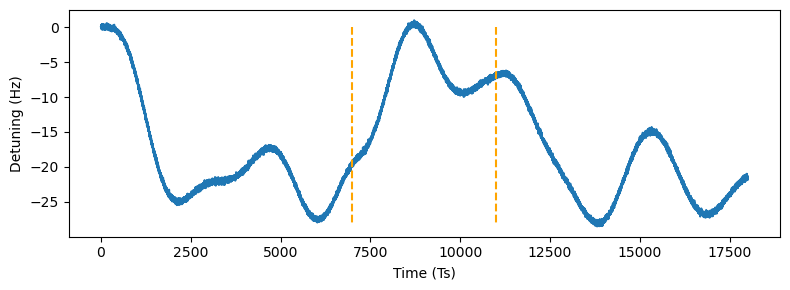

In [5]:
# --! plot simulation results --!

beam_start = args.fill_n
beam_end = beam_start + args.beam_n

plt.figure(figsize=(8,3))
plt.plot(sig_dw / 2 / np.pi)
plt.plot([beam_start, beam_start], [0, -28], color='orange', linestyle='dashed')
plt.plot([beam_end, beam_end], [0, -28], color='orange', linestyle='dashed')
plt.xlabel('Time (Ts)')
plt.ylabel('Detuning (Hz)')
plt.tight_layout()
plt.show()